### Assignment 4: Streaming Data Rupesh_koram_dz93614
 

In [2]:
pip install cartopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 66.7 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.10/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


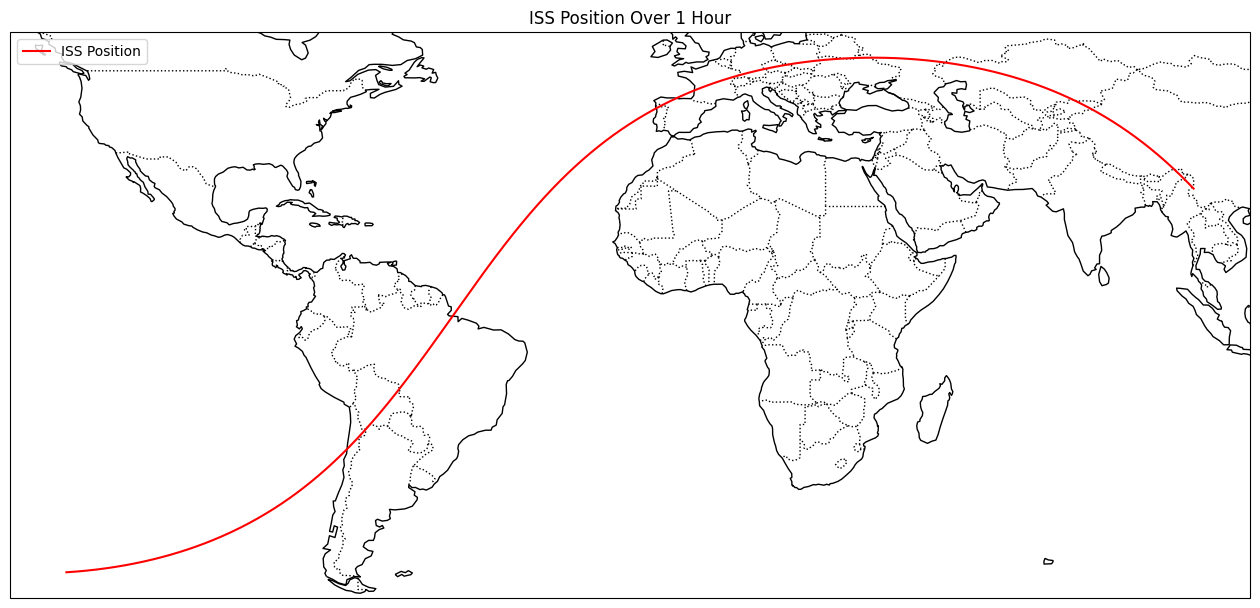

In [3]:
import requests
import time
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Initialize lists to store longitude and latitude data
longitude = []
latitude = []

# duration and interval
duration = 60 * 60  # 1 hour
interval = 5  # 5 seconds

#  fetching ISS position
def get_iss_position():
    response = requests.get("http://api.open-notify.org/iss-now.json")
    if response.status_code == 200:
        position_data = response.json()["iss_position"]
        return float(position_data["longitude"]), float(position_data["latitude"])
    else:
        print("Failed to retrieve data")
        return None, None

start_time = time.time()
while time.time() - start_time <= duration:
    lon, lat = get_iss_position()
    if lon is not None and lat is not None:
        longitude.append(lon)
        latitude.append(lat)
    time.sleep(interval)

# Plotting
fig, ax = plt.subplots(figsize=(16, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot the ISS positions on the map
ax.plot(longitude, latitude, 'r-', markersize=10, label='ISS Position', transform=ccrs.PlateCarree())
ax.set_title('ISS Position Over 1 Hour')
ax.legend(loc="upper left")
plt.show()
